In [18]:
#masukin data
import pandas as pd

df = pd.read_csv("C1eYXsTLa1D.csv")

print("Total komentar:", len(df))

df.head()

Total komentar: 996


,username,comment,total_like,total_reply,is_reply,reply_to,parent_comment
0,alvinmuhammad6222,🔥🔥🔥🔥❤️😍😂,0,2,0,NaN,NaN
1,kutut7262,@alvinmuhammad6222 GANJAR PRANOWO SAJA SALAM M...,0,0,1,alvinmuhammad6222,🔥🔥🔥🔥❤️😍😂
2,kutut7262,"@alvinmuhammad6222 NEGARA ADIL, MARITIM, LESTA...",0,0,1,alvinmuhammad6222,🔥🔥🔥🔥❤️😍😂
3,tavhir,Isep isep terus,3,2,0,NaN,NaN
4,kutut7262,@tavhir GANJAR PRANOWO SAJA SALAM METAL DARI P...,0,0,1,tavhir,Isep isep terus


In [19]:
#clean data
import re

def clean_text(text):

    text = str(text).lower()

    # remove URL
    text = re.sub(r"http\S+", "", text)

    # remove emoji & punctuation
    text = re.sub(r"[^\w\s]", "", text)

    return text


df["clean_comment"] = df["comment"].apply(clean_text)

In [20]:
df

,username,comment,total_like,total_reply,is_reply,reply_to,parent_comment,clean_comment
0,alvinmuhammad6222,🔥🔥🔥🔥❤️😍😂,0,2,0,NaN,NaN,
1,kutut7262,@alvinmuhammad6222 GANJAR PRANOWO SAJA SALAM M...,0,0,1,alvinmuhammad6222,🔥🔥🔥🔥❤️😍😂,alvinmuhammad6222 ganjar pranowo saja salam me...
2,kutut7262,"@alvinmuhammad6222 NEGARA ADIL, MARITIM, LESTA...",0,0,1,alvinmuhammad6222,🔥🔥🔥🔥❤️😍😂,alvinmuhammad6222 negara adil maritim lestari ...
3,tavhir,Isep isep terus,3,2,0,NaN,NaN,isep isep terus
4,kutut7262,@tavhir GANJAR PRANOWO SAJA SALAM METAL DARI P...,0,0,1,tavhir,Isep isep terus,tavhir ganjar pranowo saja salam metal dari pd...
...,...,...,...,...,...,...,...,...
991,nayarisk_,@nitavirda_ Seriusan emangnya bisa bantu nurun...,0,0,1,nayarisk_,Lihat body kak fero makin nambah ideal aja kas...,nitavirda_ seriusan emangnya bisa bantu nuruni...
992,nitavirda_,@nayarisk_ Ohh ternyata kaka juga order di @ni...,0,0,1,nayarisk_,Lihat body kak fero makin nambah ideal aja kas...,nayarisk_ ohh ternyata kaka juga order di nice...
993,nayarisk_,@anatasyafitri_ Jadi penasaran pengin cobain l...,0,0,1,nayarisk_,Lihat body kak fero makin nambah ideal aja kas...,anatasyafitri_ jadi penasaran pengin cobain la...
994,annsalstarii,😍😍😍,4,0,0,NaN,NaN,


In [21]:
# length
df["char_length"] = df["clean_comment"].apply(len)

# word count
df["word_count"] = df["clean_comment"].apply(
    lambda x: len(x.split())
)

# replies
df["total_reply"] = df["total_reply"].fillna(0)

# likes
df["total_like"] = df["total_like"].fillna(0)

# punctuation ratio

import string

def count_punct(text):

    text = str(text)   # 🔥 ini kunci fix

    count = sum([
        1 for char in text
        if char in string.punctuation
    ])

    return count

df["punct"] = df["comment"].apply(count_punct)

In [22]:
df["unique_words"] = df["clean_comment"].apply(
    lambda x: len(set(x.split()))
)

df["unique_ratio"] = (
    df["unique_words"] /
    (df["word_count"] + 1)
)

In [23]:
features = [
    "char_length",
    "word_count",
    "unique_words",
    "unique_ratio",
    "total_reply"
]

for col in features:

    df[col] = (
        df[col] - df[col].min()
    ) / (
        df[col].max() - df[col].min() + 1e-6
    )

In [24]:
df["influence_score"] = (

    df["char_length"] * 0.25 +

    df["word_count"] * 0.20 +

    df["unique_words"] * 0.20 +

    df["unique_ratio"] * 0.15 +

    df["total_reply"] * 0.10 +

    df["total_like"] * 0.10
)

In [25]:
top_comments = df.sort_values(
    by="influence_score",
    ascending=False
).head(50)

In [26]:
top_comments[
    ["username", "comment"]
].to_excel(
    "output/top_50_comments_to_label.xlsx",
    index=False
)

In [27]:
data = pd.read_excel("labelled_comments.xlsx")

import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(
    stopwords.words("indonesian")
)

def remove_stopwords(text):

    words = text.split()

    filtered = [
        w for w in words
        if w not in stop_words
    ]

    return " ".join(filtered)

df["processed_text"] = df[
    "clean_comment"
].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nitar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X_text = tfidf.fit_transform(
    df["processed_text"]
)

In [30]:
import numpy as np

numeric_features = df[
    ["char_length",
     "total_reply",
     "total_like"]
].values

X_final = np.hstack([
    X_text.toarray(),
    numeric_features
])

In [31]:
df = df.merge(
    data[["comment", "sentiment_score"]],
    on="comment",
    how="left"
)

In [ ]:
y = df["sentiment_score"]

In [34]:
df_labeled = df.dropna(
    subset=["sentiment_score"]
)
numeric_features = df_labeled[
    ["char_length",
     "total_reply",
     "total_like"]
].values
X_text_labeled = X_text[
    df_labeled.index
]
X_final = np.hstack([
    X_text_labeled.toarray(),
    numeric_features
])
y = df_labeled["sentiment_score"]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=150, random_state=42)

In [39]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.23939393939393938


In [ ]:
#MAE tuh rata2 error model berapa, 2.4% error

In [ ]:
# ini train pake df_labeled tapi mau prediksi all df

In [40]:
# numeric full
numeric_full = df[
    ["char_length",
     "total_reply",
     "total_like"]
].values
# combine full features
X_full = np.hstack([
    X_text.toarray(),
    numeric_full
])
# predict semua
df["predicted_score"] = model.predict(
    X_full
)

In [42]:
df.to_excel("df.xlsx")

In [43]:
df_labeled["predicted_score"] = model.predict(
    X_final
)

df_labeled[
    ["comment",
     "sentiment_score",
     "predicted_score"]
].head(10)

C:\Users\nitar\AppData\Local\Temp\ipykernel_25076\1964111745.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_labeled["predicted_score"] = model.predict(


,comment,sentiment_score,predicted_score
21,dapet apa sih??? udh gak laku ya sinetronnya?,-0.5,-0.050000
28,Pantesan jadi Komisaris😂,-1.0,-0.393333
31,Jejak digital .... selamat jadi komisaris😂,-0.5,-0.310000
33,👏,1.0,0.986667
204,Bingun sama artis artis mereka padahal rata ra...,-0.5,-0.100000
207,"@adya_llss itu hak mbak, terserah pilih siapa",0.0,0.183333
407,👏,1.0,0.986667
436,ALL IN PRABOWO ✌️🔥,1.0,1.000000
448,Jika hanya ada 1 suara di Ambon dalam Pemiliha...,1.0,0.980000
472,Makin Mantap Pilih nomer 2 All in Prabowo Love...,1.0,0.883333


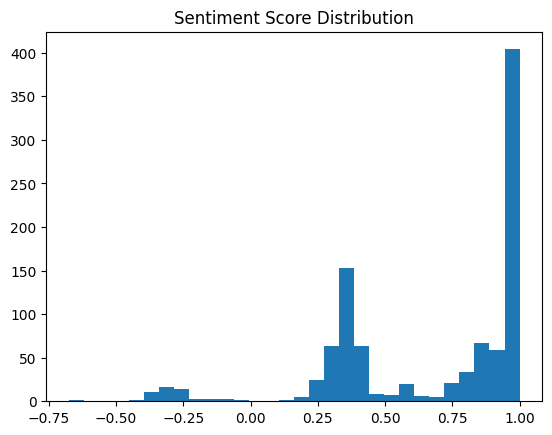

In [44]:
import matplotlib.pyplot as plt

plt.hist(
    df["predicted_score"],
    bins=30
)

plt.title("Sentiment Score Distribution")

plt.show()

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# load data
df = pd.read_excel("df.xlsx")

# isi NaN
df["clean_comment"] = df["clean_comment"].fillna("")

# daftar nama lawan
opponent_names = [
    "anis",
    "anies",
    "ganjar",
    "ganjar pranowo",
    "amin",
    "mahfud",
    "mahfud md"
]

# buat fitur mention opponent
df["mention_opponent"] = df["clean_comment"].apply(
    lambda x: int(
        any(name in x for name in opponent_names)
    )
)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=3000
)

X_text = tfidf.fit_transform(df["clean_comment"])

# fitur tambahan
X_extra = df[["mention_opponent"]].values * 5

# gabung fitur
X = hstack([X_text, X_extra])

In [2]:
df

,Unnamed: 0,username,comment,total_like,total_reply,is_reply,reply_to,parent_comment,clean_comment,char_length,word_count,punct,unique_words,unique_ratio,influence_score,processed_text,sentiment_score,predicted_score,mention_opponent
0,0,alvinmuhammad6222,🔥🔥🔥🔥❤️😍😂,0,0.028986,0,NaN,NaN,,0.000000,0.000000,0,0.000000,0.000000,0.002899,NaN,NaN,0.970000,0
1,1,kutut7262,@alvinmuhammad6222 GANJAR PRANOWO SAJA SALAM M...,0,0.000000,1,alvinmuhammad6222,🔥🔥🔥🔥❤️😍😂,alvinmuhammad6222 ganjar pranowo saja salam me...,0.248894,0.251799,12,0.238095,0.714869,0.267432,alvinmuhammad6222 ganjar pranowo salam metal p...,NaN,0.256667,1
2,2,kutut7262,"@alvinmuhammad6222 NEGARA ADIL, MARITIM, LESTA...",0,0.000000,1,alvinmuhammad6222,🔥🔥🔥🔥❤️😍😂,alvinmuhammad6222 negara adil maritim lestari ...,0.121681,0.093525,6,0.114286,0.882352,0.204335,alvinmuhammad6222 negara adil maritim lestari ...,NaN,0.363333,1
3,3,tavhir,Isep isep terus,3,0.028986,0,NaN,NaN,isep isep terus,0.016593,0.021583,0,0.019048,0.514705,0.392379,isep isep,NaN,0.863333,0
4,4,kutut7262,@tavhir GANJAR PRANOWO SAJA SALAM METAL DARI P...,0,0.000000,1,tavhir,Isep isep terus,tavhir ganjar pranowo saja salam metal dari pd...,0.236726,0.251799,12,0.238095,0.714869,0.264390,tavhir ganjar pranowo salam metal pdi perjuang...,NaN,0.256667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,991,nayarisk_,@nitavirda_ Seriusan emangnya bisa bantu nurun...,0,0.000000,1,nayarisk_,Lihat body kak fero makin nambah ideal aja kas...,nitavirda_ seriusan emangnya bisa bantu nuruni...,0.090708,0.086331,4,0.114286,0.950225,0.205334,nitavirda_ seriusan emangnya bantu nurunin bb ...,NaN,0.393333,0
992,992,nitavirda_,@nayarisk_ Ohh ternyata kaka juga order di @ni...,0,0.000000,1,nayarisk_,Lihat body kak fero makin nambah ideal aja kas...,nayarisk_ ohh ternyata kaka juga order di nice...,0.121681,0.129496,5,0.152381,0.866872,0.216827,nayarisk_ ohh kaka order niceslim_ kak aja kem...,NaN,0.363333,0
993,993,nayarisk_,@anatasyafitri_ Jadi penasaran pengin cobain l...,0,0.000000,1,nayarisk_,Lihat body kak fero makin nambah ideal aja kas...,anatasyafitri_ jadi penasaran pengin cobain la...,0.133850,0.122302,6,0.161905,0.972221,0.236137,anatasyafitri_ penasaran pengin cobain lansung...,NaN,0.330000,0
994,994,annsalstarii,😍😍😍,4,0.000000,0,NaN,NaN,,0.000000,0.000000,0,0.000000,0.000000,0.400000,NaN,NaN,0.986667,0


In [4]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

from scipy.sparse import hstack

# Load data
df = pd.read_excel("df.xlsx")

# =========================
# STEP 1 — Ambil data yang sudah ada label
# =========================

df_labeled = df[
    df["sentiment_score"].notna()
].copy()

# Ini penting:
# y = target (nilai sentimen manual lo)

y = df_labeled["sentiment_score"]

# =========================
# STEP 2 — Buat fitur opponent
# =========================

opponent_names = [
    "anis",
    "anies",
    "ganjar",
    "ganjar pranowo",
    "amin",
    "mahfud",
    "mahfud md"
]

df_labeled["mention_opponent"] = df_labeled[
    "clean_comment"
].apply(
    lambda x: int(
        any(name in str(x) for name in opponent_names)
    )
)

# =========================
# STEP 3 — TF-IDF Text
# =========================

tfidf = TfidfVectorizer(
    max_features=3000
)

X_text = tfidf.fit_transform(
    df_labeled["clean_comment"].astype(str)
)

# =========================
# STEP 4 — Gabung fitur tambahan
# =========================

X_extra = df_labeled[
    ["mention_opponent"]
].values * 5   # weight biar kuat

X = hstack([X_text, X_extra])

# =========================
# STEP 5 — Split train-test
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# STEP 6 — Train Model
# =========================

model = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

# =========================
# STEP 7 — Predict Test
# =========================

y_pred = model.predict(X_test)

# =========================
# STEP 8 — Hitung MAE
# =========================

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.28969696969696973


In [9]:
# =========================
# PREPARE ALL DATA
# =========================

df["mention_opponent"] = df[
    "clean_comment"
].apply(
    lambda x: int(
        any(name in str(x) for name in opponent_names)
    )
)

X_text_all = tfidf.transform(
    df["clean_comment"].astype(str)
)

X_extra_all = df[
    ["mention_opponent"]
].values * 3

X_all = hstack([
    X_text_all,
    X_extra_all
])

# =========================
# PREDICT
# =========================

df["predicted_score"] = model.predict(
    X_all
)

In [5]:
## ini untuk dikali minus

# =========================
# PREPARE ALL DATA
# =========================

df["mention_opponent"] = df["clean_comment"].apply(
    lambda x: int(
        any(name in str(x) for name in opponent_names)
    )
)

X_text_all = tfidf.transform(
    df["clean_comment"].astype(str)
)

# Kasih bobot lebih kuat
X_extra_all = df[["mention_opponent"]].values * 3

X_all = hstack([
    X_text_all,
    X_extra_all
])

# =========================
# PREDICT
# =========================

# Prediksi awal dari model
df["predicted_score"] = model.predict(X_all)

# =========================
# FORCE RULE (INI BAGIAN PENTING)
# Jika ada opponent mention -> kali minus
# =========================

df.loc[
    df["mention_opponent"] == 1,
    "predicted_score"
] *= -1


# =========================
# OPTIONAL: y_pred juga
# =========================

y_pred = df["predicted_score"].values

In [6]:
df

,Unnamed: 0,username,comment,total_like,total_reply,is_reply,reply_to,parent_comment,clean_comment,char_length,word_count,punct,unique_words,unique_ratio,influence_score,processed_text,sentiment_score,predicted_score,mention_opponent
0,0,alvinmuhammad6222,🔥🔥🔥🔥❤️😍😂,0,0.028986,0,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,0.000000,0.002899,NaN,NaN,0.970000,0
1,1,kutut7262,@alvinmuhammad6222 GANJAR PRANOWO SAJA SALAM M...,0,0.000000,1,alvinmuhammad6222,🔥🔥🔥🔥❤️😍😂,alvinmuhammad6222 ganjar pranowo saja salam me...,0.248894,0.251799,12,0.238095,0.714869,0.267432,alvinmuhammad6222 ganjar pranowo salam metal p...,NaN,-0.463333,1
2,2,kutut7262,"@alvinmuhammad6222 NEGARA ADIL, MARITIM, LESTA...",0,0.000000,1,alvinmuhammad6222,🔥🔥🔥🔥❤️😍😂,alvinmuhammad6222 negara adil maritim lestari ...,0.121681,0.093525,6,0.114286,0.882352,0.204335,alvinmuhammad6222 negara adil maritim lestari ...,NaN,-0.793333,1
3,3,tavhir,Isep isep terus,3,0.028986,0,NaN,NaN,isep isep terus,0.016593,0.021583,0,0.019048,0.514705,0.392379,isep isep,NaN,0.820000,0
4,4,kutut7262,@tavhir GANJAR PRANOWO SAJA SALAM METAL DARI P...,0,0.000000,1,tavhir,Isep isep terus,tavhir ganjar pranowo saja salam metal dari pd...,0.236726,0.251799,12,0.238095,0.714869,0.264390,tavhir ganjar pranowo salam metal pdi perjuang...,NaN,-0.463333,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,991,nayarisk_,@nitavirda_ Seriusan emangnya bisa bantu nurun...,0,0.000000,1,nayarisk_,Lihat body kak fero makin nambah ideal aja kas...,nitavirda_ seriusan emangnya bisa bantu nuruni...,0.090708,0.086331,4,0.114286,0.950225,0.205334,nitavirda_ seriusan emangnya bantu nurunin bb ...,NaN,0.790000,0
992,992,nitavirda_,@nayarisk_ Ohh ternyata kaka juga order di @ni...,0,0.000000,1,nayarisk_,Lihat body kak fero makin nambah ideal aja kas...,nayarisk_ ohh ternyata kaka juga order di nice...,0.121681,0.129496,5,0.152381,0.866872,0.216827,nayarisk_ ohh kaka order niceslim_ kak aja kem...,NaN,0.800000,0
993,993,nayarisk_,@anatasyafitri_ Jadi penasaran pengin cobain l...,0,0.000000,1,nayarisk_,Lihat body kak fero makin nambah ideal aja kas...,anatasyafitri_ jadi penasaran pengin cobain la...,0.133850,0.122302,6,0.161905,0.972221,0.236137,anatasyafitri_ penasaran pengin cobain lansung...,NaN,0.153333,0
994,994,annsalstarii,😍😍😍,4,0.000000,0,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,0.000000,0.400000,NaN,NaN,0.970000,0


In [7]:
df.to_excel("opponent.xlsx")